In [43]:
import torch
import torch.nn as nn
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader , TensorDataset


In [44]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [45]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "without_mask" in dirs:
        print(os.path.join(root, "without_mask"))

/content/drive/MyDrive/datasets/without_mask


cuda
686
(320, 433)
RGB


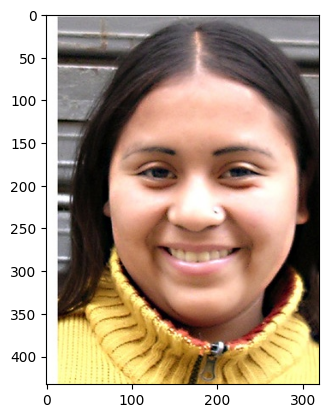

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
import os
from PIL import Image
import matplotlib.pyplot as plt

path = "/content/drive/MyDrive/datasets/without_mask"

print(len(os.listdir(path)))

img_name = os.listdir(path)[0]

img = Image.open(os.path.join(path, img_name))

print(img.size)
print(img.mode)

plt.imshow(img)
plt.show()

In [47]:
transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])

from torch.utils.data import Dataset
from PIL import Image
import os

class FaceDataset(Dataset):

    def __init__(self, path, transform=None):
        self.path = path
        self.transform = transform

        self.images = [
            f for f in os.listdir(path)
            if f.endswith(('.jpg', '.png', '.jpeg'))
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_path = os.path.join(
            self.path,
            self.images[idx]
        )

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img
    
dataset = FaceDataset(
    path,
    transform=transform
)

from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)


In [48]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ConvVAE(nn.Module):

    def __init__(self, latent_dim=128):

        super().__init__()

        # =========================
        # ENCODER
        # =========================

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=8,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.bn1 = nn.BatchNorm2d(8)

        self.conv2 = nn.Conv2d(
            8,
            16,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.bn2 = nn.BatchNorm2d(16)

        self.conv3 = nn.Conv2d(
            16,
            32,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.bn3 = nn.BatchNorm2d(32)

        self.conv4 = nn.Conv2d(
            32,
            64,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.bn4 = nn.BatchNorm2d(64)

        # Final shape:
        # [64, 2, 2]

        self.fc_mu = nn.Linear(64 * 2 * 2, latent_dim)
        self.fc_logvar = nn.Linear(64 * 2 * 2, latent_dim)

        # =========================
        # DECODER
        # =========================

        self.fc_decode = nn.Linear(
            latent_dim,
            64 * 2 * 2
        )

        self.deconv1 = nn.ConvTranspose2d(
            64,
            32,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.dbn1 = nn.BatchNorm2d(32)

        self.deconv2 = nn.ConvTranspose2d(
            32,
            16,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.dbn2 = nn.BatchNorm2d(16)

        self.deconv3 = nn.ConvTranspose2d(
            16,
            8,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.dbn3 = nn.BatchNorm2d(8)

        self.deconv4 = nn.ConvTranspose2d(
            8,
            3,
            kernel_size=4,
            stride=2,
            padding=1
        )

    # =========================
    # ENCODER
    # =========================

    def encoder(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)

        x = self.conv4(x)
        x = self.bn4(x)
        x = F.relu(x)

        # flatten
        x = torch.flatten(x, start_dim=1)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu, logvar

    # =========================
    # REPARAMETERIZATION
    # =========================

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)

        eps = torch.randn_like(std)

        z = mu + eps * std

        return z

    # =========================
    # DECODER
    # =========================

    def decoder(self, z):

        x = self.fc_decode(z)

        # reshape back to feature map
        x = x.view(-1, 64, 2, 2)

        x = self.deconv1(x)
        x = self.dbn1(x)
        x = F.relu(x)

        x = self.deconv2(x)
        x = self.dbn2(x)
        x = F.relu(x)

        x = self.deconv3(x)
        x = self.dbn3(x)
        x = F.relu(x)

        x_hat = torch.sigmoid(self.deconv4(x))

        return x_hat

    # =========================
    # FORWARD
    # =========================

    def forward(self, x):

        mu, logvar = self.encoder(x)

        z = self.reparameterize(mu, logvar)

        x_hat = self.decoder(z)

        return x_hat, mu, logvar

In [49]:
model=ConvVAE().to(device)

loss_fn=nn.MSELoss(reduction='sum')
lr=0.001
optimizer=torch.optim.Adam(model.parameters() , lr=lr)


In [53]:
epochs = 20


for epoch in range(epochs):

    total_loss = 0

    for x in loader:

       
        x=x.to(device)
        

        # Forward
        x_hat, mu, logvar = model(x)

        # Reconstruction loss
        recon_loss = loss_fn(x_hat, x)

        # KL loss
        kl_loss = -0.5 * torch.sum(
            1 + logvar - mu.pow(2) - logvar.exp()
        )
        
        beta =0.000001
        # Total
        loss = recon_loss + beta * kl_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"\nEpoch {epoch+1}")
    print(f"Total Loss: {total_loss:.2f}")
    print(f"Recon Loss: {recon_loss.item():.2f}")
    print(f"KL Loss: {kl_loss.item():.2f}")


Epoch 1
Total Loss: 62532.56
Recon Loss: 4176.84
KL Loss: 23927.50

Epoch 2
Total Loss: 52874.71
Recon Loss: 3318.19
KL Loss: 22112.93

Epoch 3
Total Loss: 45413.65
Recon Loss: 2724.51
KL Loss: 19669.98

Epoch 4
Total Loss: 42061.46
Recon Loss: 2786.02
KL Loss: 23025.45

Epoch 5
Total Loss: 40204.29
Recon Loss: 2539.05
KL Loss: 22596.32

Epoch 6
Total Loss: 38857.87
Recon Loss: 2627.37
KL Loss: 21911.77

Epoch 7
Total Loss: 37912.42
Recon Loss: 2481.52
KL Loss: 24893.31

Epoch 8
Total Loss: 37125.68
Recon Loss: 2508.13
KL Loss: 25512.88

Epoch 9
Total Loss: 36422.05
Recon Loss: 2373.36
KL Loss: 27118.30

Epoch 10
Total Loss: 35791.60
Recon Loss: 2495.22
KL Loss: 27363.72

Epoch 11
Total Loss: 35244.30
Recon Loss: 2246.06
KL Loss: 26298.43

Epoch 12
Total Loss: 34696.68
Recon Loss: 2442.28
KL Loss: 27851.27

Epoch 13
Total Loss: 34230.17
Recon Loss: 2269.10
KL Loss: 30671.12

Epoch 14
Total Loss: 33781.04
Recon Loss: 2169.75
KL Loss: 30155.56

Epoch 15
Total Loss: 33281.77
Recon Loss: 

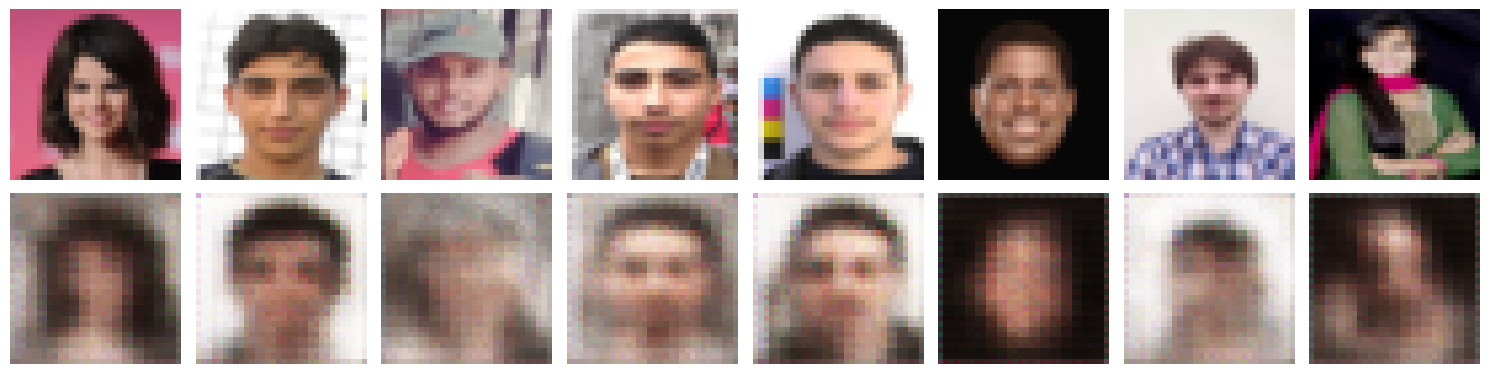

In [51]:
model.eval()

with torch.no_grad():

    # get one batch
    x = next(iter(loader))

    x = x.to(device)

    # forward pass
    x_hat, _, _ = model(x)

    # move to cpu
    x = x.cpu()
    x_hat = x_hat.cpu()

    # if using sigmoid output:
    # x_hat already in [0,1]

    # if NOT using sigmoid:
    # uncomment below
    # x_hat = torch.sigmoid(x_hat)

# ======================================
# VISUALIZATION
# ======================================

fig, axes = plt.subplots(2, 8, figsize=(15, 4))

for i in range(8):

    # ORIGINAL
    axes[0, i].imshow(
        x[i].permute(1, 2, 0)
    )

    axes[0, i].axis('off')

    # RECONSTRUCTION
    axes[1, i].imshow(
        x_hat[i].permute(1, 2, 0)
    )

    axes[1, i].axis('off')

plt.tight_layout()
plt.show()